<a href="https://colab.research.google.com/github/alimohmedelsaid26-cell/1000MLEngineer/blob/main/Household_Power_consumption_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SelectFromModel
dataset = pd.read_csv('/content/household_power_consumption.txt.zip', sep=';', header=0, low_memory=False, infer_datetime_format=True, parse_dates={'datetime':[0,1]}, index_col=['datetime'])

/tmp/ipython-input-163/3796028250.py:11: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  dataset = pd.read_csv('/content/household_power_consumption.txt.zip', sep=';', header=0, low_memory=False, infer_datetime_format=True, parse_dates={'datetime':[0,1]}, index_col=['datetime'])
/tmp/ipython-input-163/3796028250.py:11: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dataset = pd.read_csv('/content/household_power_consumption.txt.zip', sep=';', header=0, low_memory=False, infer_datetime_format=True, parse_dates={'datetime':[0,1]}, index_col=['datetime'])
/tmp/ipython-input-163/3796028250.py:11: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when day

In [ ]:
# --- STEP 1: Handle Missing Values ---
# Option B is usually better for power consumption data
dataset = dataset.ffill()

# Double check: This should print 0
print("Missing values:", dataset.isnull().sum().sum())

# --- STEP 2: Define X and y ---
X = dataset.drop(columns=['Global_active_power'])
y = dataset['Global_active_power']

# --- STEP 3: Split and Scale ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- STEP 4: Model Training (Now it will work!) ---
model = LinearRegression()
model.fit(X_train_scaled, y_train)


Missing values: 0


LinearRegression()

R2 Score: 0.9980
Mean Squared Error (MSE): 0.0015


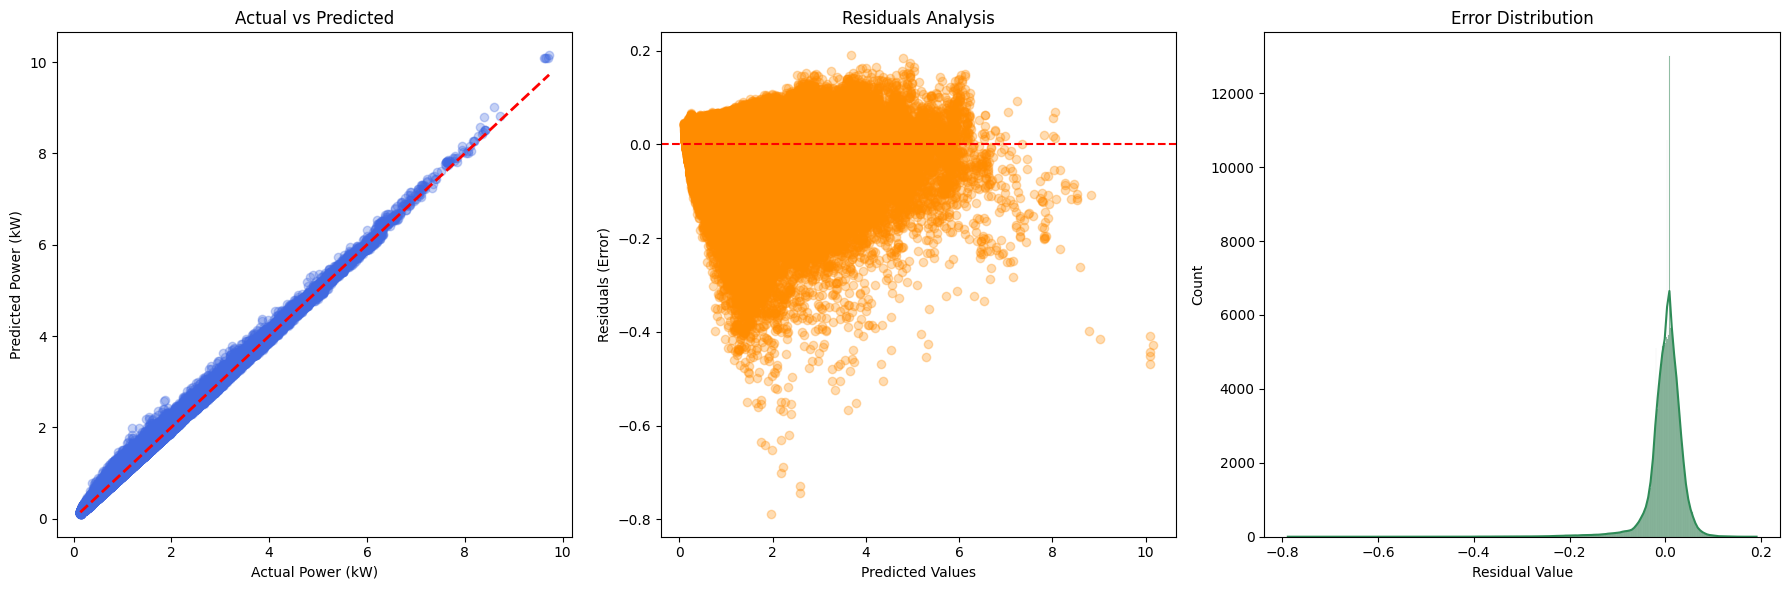

In [ ]:


# 9. Model Training
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 10. Prediction and Numerical Evaluation
y_pred = model.predict(X_test_scaled)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.4f}")

# 11. Visual Evaluation
plt.figure(figsize=(18, 6))

# Chart 1: Actual vs Predicted Values
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.3, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted')
plt.xlabel('Actual Power (kW)')
plt.ylabel('Predicted Power (kW)')


# Chart 2: Residuals Analysis (Model "Lie Detector")
plt.subplot(1, 3, 2)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.3, color='darkorange')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals Analysis')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Error)')


# Chart 3: Error Distribution
plt.subplot(1, 3, 3)
sns.histplot(residuals, kde=True, color='seagreen')
plt.title('Error Distribution')
plt.xlabel('Residual Value')


plt.tight_layout()
plt.show()